# 01. EDA — Cell2Cell 통신사 고객 이탈 예측

**입력 데이터**: `data/raw/cell2celltrain.csv` (51,047명, Target `Churn` 포함)


**목표**: 데이터 품질을 확인하고, 이탈과 관련된 핵심 패턴을 시각화·해석해서
`reports/preprocessing_report.md`에 반영할 근거를 만든다.

> `cell2cellholdout.csv`는 Target이 전부 결측이라 이 EDA에서 다루지 않는다
> (Streamlit 시연 전용).


## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# 한글 폰트 설정 (Windows는 보통 'Malgun Gothic', Mac은 'AppleGothic'.
# 아래는 다양한 OS에서 있는 폰트 중 하나를 자동으로 찾아 쓰도록 처리)
import matplotlib
candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']
available = {f.name for f in fm.fontManager.ttflist}
for c in candidates:
    if c in available:
        plt.rcParams['font.family'] = c
        break
plt.rcParams['axes.unicode_minus'] = False

ROOT_DIR = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT_DIR / "data" / "raw" / "cell2celltrain.csv"

COLOR_KEEP = "#4C72B0"
COLOR_CHURN = "#DD5E5E"

pd.set_option('display.max_columns', None)

# EDA 그래프를 저장할 폴더 (전처리 결과서 reports/preprocessing_report.md 가 참조하는 위치)
FIGURES_DIR = ROOT_DIR / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 1. 데이터 로드 및 shape·dtype 확인

In [2]:
df = pd.read_csv(DATA_PATH)
print("shape:", df.shape)
df.dtypes


shape: (51047, 58)


CustomerID                     int64
Churn                            str
MonthlyRevenue               float64
MonthlyMinutes               float64
TotalRecurringCharge         float64
DirectorAssistedCalls        float64
OverageMinutes               float64
RoamingCalls                 float64
PercChangeMinutes            float64
PercChangeRevenues           float64
DroppedCalls                 float64
BlockedCalls                 float64
UnansweredCalls              float64
CustomerCareCalls            float64
ThreewayCalls                float64
ReceivedCalls                float64
OutboundCalls                float64
InboundCalls                 float64
PeakCallsInOut               float64
OffPeakCallsInOut            float64
DroppedBlockedCalls          float64
CallForwardingCalls          float64
CallWaitingCalls             float64
MonthsInService                int64
UniqueSubs                     int64
ActiveSubs                     int64
ServiceArea                      str
H

In [3]:
df.head()


,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


## 2. 중복·결측·불가능한 값 확인

가이드 권장 EDA 순서(`shape·dtype → 중복·결측·불가능한 값 → Target 분포 → ...`)를 그대로 따른다.


In [4]:
# 중복 확인
print("CustomerID 중복 수:", df['CustomerID'].duplicated().sum())
print("전체 행 중복 수:", df.duplicated().sum())


CustomerID 중복 수: 0
전체 행 중복 수: 0


In [5]:
# 결측치 확인
null_counts = df.isnull().sum()
null_ratio = (null_counts / len(df) * 100).round(2)
quality_summary = pd.DataFrame({'결측수': null_counts, '결측비율(%)': null_ratio})
quality_summary[quality_summary['결측수'] > 0].sort_values('결측수', ascending=False)


,결측수,결측비율(%)
AgeHH2,909,1.78
AgeHH1,909,1.78
PercChangeRevenues,367,0.72
PercChangeMinutes,367,0.72
MonthlyRevenue,156,0.31
MonthlyMinutes,156,0.31
RoamingCalls,156,0.31
OverageMinutes,156,0.31
DirectorAssistedCalls,156,0.31
TotalRecurringCharge,156,0.31


In [6]:
# 불가능한 값(음수 등) 확인 - 수치형 컬럼 min이 음수인 게 있는지
num_cols_check = df.select_dtypes(include='number').columns.drop('CustomerID')
neg_check = (df[num_cols_check] < 0).sum()
print("음수값이 있는 컬럼:")
print(neg_check[neg_check > 0] if (neg_check > 0).any() else "없음")


음수값이 있는 컬럼:
MonthlyRevenue              3
TotalRecurringCharge        8
PercChangeMinutes       26816
PercChangeRevenues      28408
CurrentEquipmentDays       76
dtype: int64


**품질 요약**: CustomerID·행 중복 없음. 58개 컬럼 중 14개에 결측(최대 1.78%),
음수 등 불가능한 값은 발견되지 않았다. 다만 `ServiceArea`(747개 고유값),
`HandsetPrice`(숫자+'Unknown' 혼재), `AgeHH1/AgeHH2`(0-센티널과 진짜 결측 혼재) 는
그대로 쓰기 어려워 전처리 단계(`src/data.py`)에서 별도 정리가 필요하다.

## 3. Target(Churn) 분포

In [7]:
y = (df['Churn'] == 'Yes').astype(int)
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True) * 100).round(2))


Churn
No     36336
Yes    14711
Name: count, dtype: int64
Churn
No     71.18
Yes    28.82
Name: proportion, dtype: float64


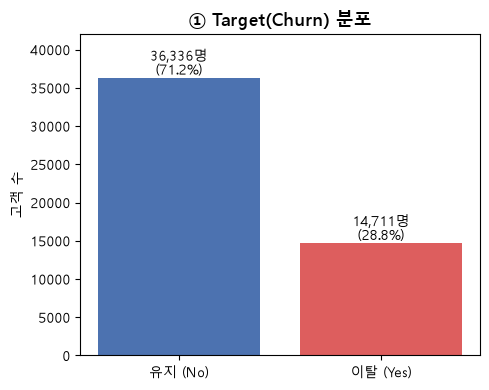

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['Churn'].value_counts()
bars = ax.bar(['유지 (No)', '이탈 (Yes)'], [counts['No'], counts['Yes']],
              color=[COLOR_KEEP, COLOR_CHURN])
for b, v in zip(bars, [counts['No'], counts['Yes']]):
    ax.text(b.get_x() + b.get_width()/2, v + 400, f'{v:,}명\n({v/len(df):.1%})',
            ha='center', fontsize=10)
ax.set_title('① Target(Churn) 분포', fontsize=13, fontweight='bold')
ax.set_ylabel('고객 수')
ax.set_ylim(0, 42000)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_target_distribution.png", dpi=140, bbox_inches="tight")
plt.show()


> **관찰**: 이탈 28.8% / 유지 71.2%로 중간 정도의 불균형이다. 따라서 Accuracy만으로
> 평가하면 안 되고 Recall·F1·PR-AUC를 함께 봐야 하며, `class_weight='balanced'`를
> 모델링 1순위로 시도하는 게 합리적이다. 다만 이 비율이 이 통신사의 현재 이탈률과
> 같다고 단정할 수는 없다(수집 시점 불명).

## 4. 수치형 Feature별 이탈률 — CurrentEquipmentDays

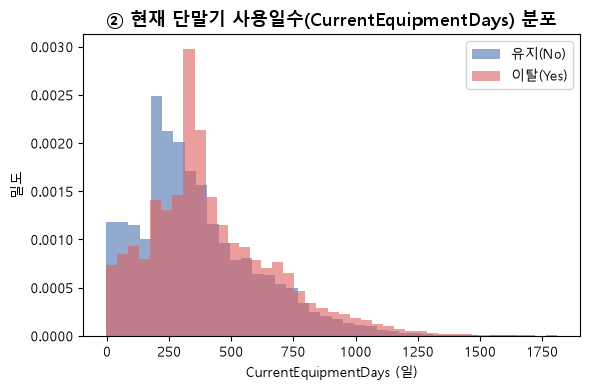

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
d0 = df.loc[y == 0, 'CurrentEquipmentDays'].dropna()
d1 = df.loc[y == 1, 'CurrentEquipmentDays'].dropna()
ax.hist(d0, bins=40, alpha=0.6, label='유지(No)', color=COLOR_KEEP, density=True)
ax.hist(d1, bins=40, alpha=0.6, label='이탈(Yes)', color=COLOR_CHURN, density=True)
ax.set_title('② 현재 단말기 사용일수(CurrentEquipmentDays) 분포', fontsize=13, fontweight='bold')
ax.set_xlabel('CurrentEquipmentDays (일)')
ax.set_ylabel('밀도')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_equipmentdays_by_churn.png", dpi=140, bbox_inches="tight")
plt.show()


> **관찰**: 이탈 고객이 유지 고객보다 현재 단말기를 더 오래 써온 쪽에 살짝
> 치우쳐 있다 — 이 데이터에서 Target과 상관계수가 가장 높은 변수(r≈0.10)다.
> 따라서 "오래된 단말기를 쓰는 고객에게 업그레이드 오퍼를 제안"하는 유지 전략의
> 근거가 될 수 있다. 다만 상관계수 자체가 약해 이 변수 하나로 이탈을 설명하긴 어렵다.

## 5. 범주형 Feature별 이탈률 — 리텐션팀 접촉 이력 (누수 의심)

MadeCallToRetentionTeam
No     0.282443
Yes    0.450430
Name: Churn, dtype: float64


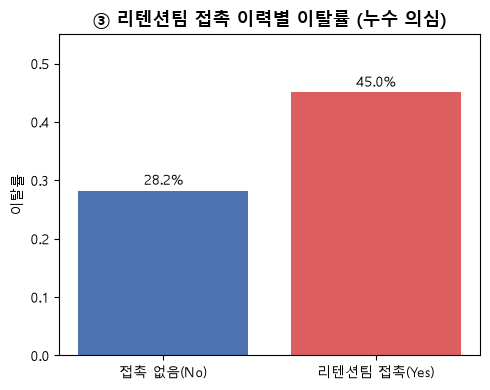

In [10]:
g = df.groupby('MadeCallToRetentionTeam')['Churn'].apply(lambda s: (s == 'Yes').mean())
print(g)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['접촉 없음(No)', '리텐션팀 접촉(Yes)'], [g['No'], g['Yes']],
              color=[COLOR_KEEP, COLOR_CHURN])
for b, v in zip(bars, [g['No'], g['Yes']]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
ax.set_title('③ 리텐션팀 접촉 이력별 이탈률 (누수 의심)', fontsize=13, fontweight='bold')
ax.set_ylabel('이탈률')
ax.set_ylim(0, 0.55)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_retentioncall_churn_rate.png", dpi=140, bbox_inches="tight")
plt.show()


> **관찰**: 리텐션팀에게 연락받은 고객의 이탈률(45.0%)이 없는 고객(28.2%)보다
> 훨씬 높다. "연락하면 이탈이 늘어난다"가 아니라 **"이탈 위험 신호가 이미 보인
> 고객을 리텐션팀이 먼저 골라 연락했을 가능성(역인과관계)"**이 높다. 따라서 이
> 컬럼(`RetentionCalls`, `RetentionOffersAccepted`, `MadeCallToRetentionTeam`)은
> 포함/제외 두 버전을 모두 만들어 모델링 단계(D)에서 비교하기로 했다. 다만 진짜
> 역인과관계인지는 이 데이터만으로 확정할 수 없다.

## 6. 단말기 웹 사용 가능 여부별 이탈률

HandsetWebCapable
No     0.373525
Yes    0.278917
Name: Churn, dtype: float64


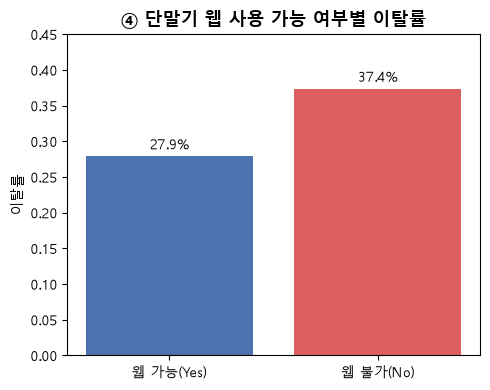

In [11]:
g = df.groupby('HandsetWebCapable')['Churn'].apply(lambda s: (s == 'Yes').mean())
print(g)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['웹 가능(Yes)', '웹 불가(No)'], [g['Yes'], g['No']],
              color=[COLOR_KEEP, COLOR_CHURN])
for b, v in zip(bars, [g['Yes'], g['No']]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)
ax.set_title('④ 단말기 웹 사용 가능 여부별 이탈률', fontsize=13, fontweight='bold')
ax.set_ylabel('이탈률')
ax.set_ylim(0, 0.45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_webcapable_churn_rate.png", dpi=140, bbox_inches="tight")
plt.show()


> **관찰**: 웹을 지원하지 않는(구형) 단말기를 쓰는 고객의 이탈률(37.4%)이 웹
> 지원 단말기 사용 고객(27.9%)보다 뚜렷이 높다. 단말기 세대 관련 변수들을
> 묶어서 "단말기 노후도" 관점의 유지 전략(업그레이드 프로모션)을 설계할 근거가
> 된다. 다만 웹 지원 여부와 가입 시기가 서로 얽혀 있을 수 있어, 단말기 자체의
> 효과인지 가입 시점의 효과인지는 구분이 어렵다.

## 7. 신용등급별 이탈률 — 비직관적 패턴

CreditRating
1-Highest    0.308378
2-High       0.300742
3-Good       0.310107
4-Medium     0.261154
5-Low        0.220957
6-VeryLow    0.274306
7-Lowest     0.289499
Name: Churn, dtype: float64


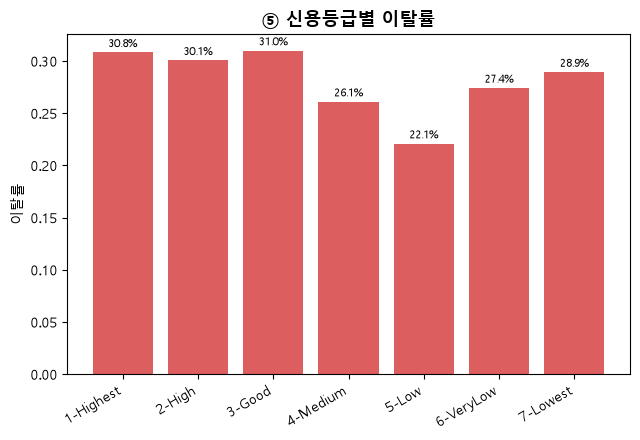

In [12]:
order = ['1-Highest', '2-High', '3-Good', '4-Medium', '5-Low', '6-VeryLow', '7-Lowest']
g = df.groupby('CreditRating')['Churn'].apply(lambda s: (s == 'Yes').mean()).reindex(order)
print(g)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(order, g.values, color=COLOR_CHURN)
for b, v in zip(bars, g.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.1%}', ha='center', fontsize=8)
ax.set_title('⑤ 신용등급별 이탈률', fontsize=13, fontweight='bold')
ax.set_ylabel('이탈률')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_creditrating_churn_rate.png", dpi=140, bbox_inches="tight")
plt.show()


> **관찰**: 신용등급이 가장 좋은 `1-Highest`(30.8%)와 중간 등급 `3-Good`(31.0%)의
> 이탈률이 오히려 `5-Low`(22.1%)보다 높다 — "신용등급이 좋을수록 이탈률이 낮을
> 것"이라는 일반적 기대와 다른 방향이다. 따라서 `CreditRating`을 넣을 때 이
> 비선형 관계를 트리 계열 모델이 잘 잡아내는지 확인하고, 선형 모델에서는 계수
> 해석에 주의가 필요하다. 다만 원인은 이 데이터만으로 단정할 수 없다.

## 8. 지역(ServiceArea)별 이탈률 편차

3자리 축약 후 고유값 수: 57 (원본 747개에서 축소)


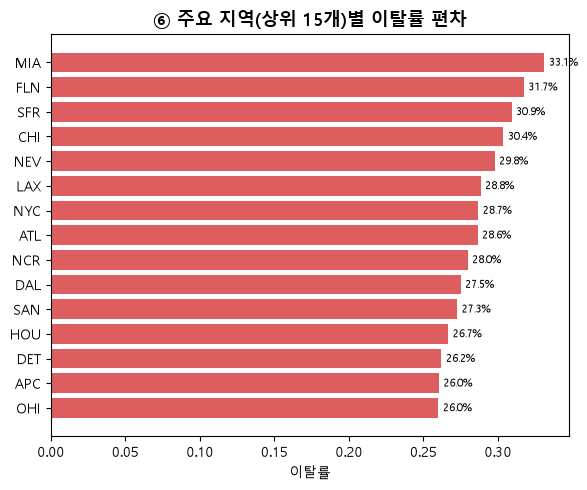

In [13]:
df['region3'] = df['ServiceArea'].astype(str).str[:3]
print("3자리 축약 후 고유값 수:", df['region3'].nunique(), "(원본 747개에서 축소)")

top15 = df['region3'].value_counts().head(15).index
g = df[df['region3'].isin(top15)].groupby('region3')['Churn'] \
        .apply(lambda s: (s == 'Yes').mean()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.barh(g.index[::-1], g.values[::-1], color=COLOR_CHURN)
for b, v in zip(bars, g.values[::-1]):
    ax.text(v + 0.003, b.get_y() + b.get_height()/2, f'{v:.1%}', va='center', fontsize=8)
ax.set_title('⑥ 주요 지역(상위 15개)별 이탈률 편차', fontsize=13, fontweight='bold')
ax.set_xlabel('이탈률')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_region_churn_rate.png", dpi=140, bbox_inches="tight")
plt.show()


> **관찰**: 같은 상위 15개 대도시권 안에서도 이탈률이 지역마다 꽤 차이가 난다.
> 따라서 지역 변수를 완전히 버리지 않고, 원본 747개 고유값을 앞 3자리 대도시권
> 코드로 축약해서(`src/data.py`) Feature로 유지하기로 했다. 다만 지역별 차이가
> 통신 인프라 때문인지 고객층 특성 때문인지는 이 데이터로 구분할 수 없다.

## 9. 수치형 Feature 상위 12개와 Target의 상관계수

CurrentEquipmentDays       0.104
RetentionCalls             0.065
TotalRecurringCharge      -0.061
MonthlyMinutes            -0.050
OffPeakCallsInOut         -0.041
HandsetModels             -0.040
PeakCallsInOut            -0.040
ReceivedCalls             -0.037
CustomerCareCalls         -0.036
RetentionOffersAccepted    0.035
UniqueSubs                 0.035
InboundCalls              -0.034
Name: Churn, dtype: float64


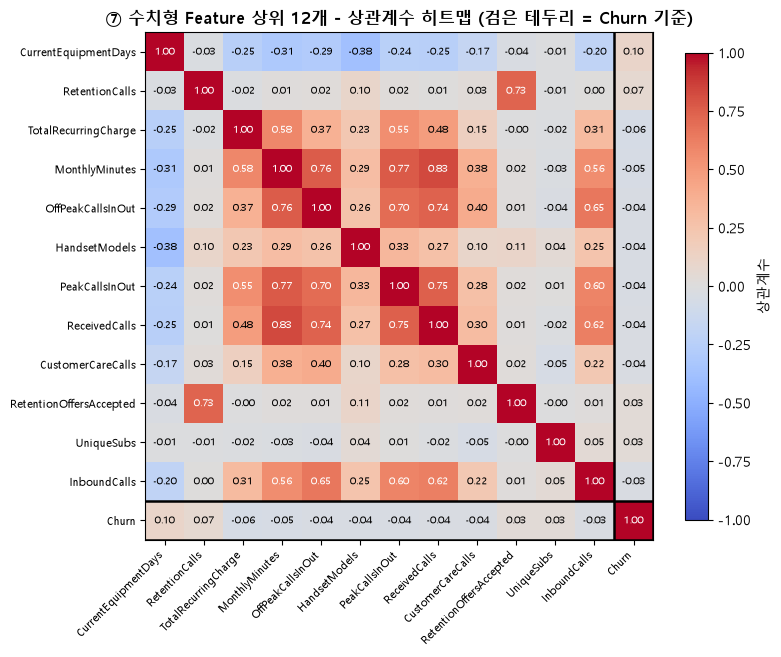

In [14]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'CustomerID']
corr_to_target = df[num_cols].assign(Churn=y).corr()['Churn'].drop('Churn') \
                     .sort_values(key=abs, ascending=False).head(12)
top_features = corr_to_target.index.tolist()
print(corr_to_target.round(3))

# Top 12 Feature + Churn 전체를 놓고 상관계수 행렬(히트맵)을 그린다
corr_matrix = df[top_features].assign(Churn=y).corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=7)

# Churn 행/열을 테두리로 강조 (가장 보고 싶은 기준선이므로)
churn_idx = labels.index('Churn')
ax.axhline(churn_idx - 0.5, color='black', linewidth=1.8)
ax.axhline(churn_idx + 0.5, color='black', linewidth=1.8)
ax.axvline(churn_idx - 0.5, color='black', linewidth=1.8)
ax.axvline(churn_idx + 0.5, color='black', linewidth=1.8)

fig.colorbar(im, ax=ax, shrink=0.8, label='상관계수')
ax.set_title('⑦ 수치형 Feature 상위 12개 - 상관계수 히트맵 (검은 테두리 = Churn 기준)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_numeric_corr_with_target.png", dpi=140, bbox_inches="tight")
plt.show()

> **관찰**: 가장 강한 변수(`CurrentEquipmentDays`)도 Churn과의 상관계수가 0.10 수준이고, 상위 12개 변수 대부분이 ±0.03~0.10 사이에 몰려 있다. 개별 변수의 설명력이 전반적으로 약하다 — 참고로 로지스틱 회귀 단일 모델 사전 테스트에서도 AUC가 0.61 수준에 그쳤다. 한편 히트맵으로 보면 Target과 무관하게 **`MonthlyMinutes`와 `ReceivedCalls`가 상관계수 0.83으로 거의 같이 움직이는 다중공선성**이 눈에 띈다 — 통화량이 많을수록 받는 전화도 많아지는 자연스러운 관계로 보이며, 선형 계열 모델(Logistic Regression)에서는 이런 변수 쌍이 계수 해석을 불안정하게 만들 수 있어 유의해야 한다. 종합하면 단일 변수 규칙이 아니라 **여러 변수의 조합·상호작용을 잡아내는 Boosting 계열 모델이 특히 중요**할 것으로 예상된다. 다만 선형 상관계수만 본 것이라 비선형 관계는 여기서 안 보였을 수 있다.

## 10. 비즈니스 인사이트 3가지

1. **단말기 노후도(오래 사용·웹 미지원)가 이탈과 관련이 있다.** 오래된 단말기를 쓰는
   고객에게 업그레이드 프로모션을 제안하는 전략의 근거가 된다.
2. **리텐션팀 접촉 이력은 "이미 위험 신호가 보인 고객"의 지표일 가능성이 크다.**
   이 변수를 그대로 모델에 넣으면 해석이 왜곡될 수 있어, 성능·해석 가능성을 모두
   고려해 포함 여부를 결정해야 한다.
3. **지역(대도시권)별로 이탈률 차이가 존재한다.** 전국 단일 전략보다 지역별
   캠페인 강도를 다르게 가져갈 근거가 된다.


## 11. 인사이트에 따른 전처리·모델링 결정 3가지

1. **ServiceArea(747개 고유값) → 대도시권 코드(3자리) 축약 + 희소 지역 그룹화**
   (근거: 8장) — 그대로 원-핫하면 차원이 폭발하고 표본이 적은 지역은 통계적으로
   불안정하다.
2. **리텐션 관련 3개 컬럼 → 포함/제외 두 버전 모두 생성** (근거: 5장) — 역인과관계
   의심 때문에 미리 빼거나 넣지 않고, 모델링 단계에서 성능·해석 비교 후 결정한다.
3. **AgeHH1/AgeHH2 결측치 → 중앙값 대신 0으로 대체** — 이 데이터가 이미 0을
   "해당 세대원 없음"으로 광범위하게 쓰고 있어(AgeHH1==0 13,917건 등), 기존
   인코딩 관례와 일관되게 처리하는 것이 중앙값보다 합리적이다.

(자세한 전처리 구현은 `src/data.py`, 결과 정리는 `reports/preprocessing_report.md` 참고)


## 12. 데이터 한계

- 개별 Feature와 Target의 상관관계가 전반적으로 약하다(9장, 최댓값 0.10). 이는 실제
  통신 이탈 예측이 학계에서도 어려운 문제로 알려진 것과 일치하지만, 다른 도메인
  대비 최종 모델 성능이 낮게 나올 수 있음을 발표에서 미리 설명할 필요가 있다.
- 리텐션 컬럼의 역인과관계 여부(5장)는 이 데이터만으로 확정할 수 없으며, 모델링
  단계의 비교 실험 결과에 따라 판단이 달라질 수 있다.
- `NewCellphoneUser`/`NotNewCellphoneUser` 두 컬럼이 서로 완전히 배타적이지 않다
  (No/No 조합이 34,188건 존재). 정확한 정의 차이가 데이터 사전에 없어 추가 확인이
  필요하다.
- 데이터 수집 시점이 명시돼 있지 않아 현재 통신 시장 상황과 얼마나 다른지 알 수 없다.
